# Assignment Instructions - Part 1: Explore an Analytical Component in a Model

This part uses symbolic software to explore an analytical component of a model. The goal to understand how a mathematical function can be built into a larger model and how its parameters shape behavior.  

Let's start with a standard exponential growth model:

$$P(t) = P_0 e^{rt}$$

Where:

- $t$ is the independent variable (time).
- $P_0$ is the initial population value.
- $r$ is the growth-rate parameter.

Now we are going to type up the same model in the Symbolic Python Libray which can work with analytical symbols rather than discrete numbers:

In [1]:
# Define symbols and model
import sympy as sp

t = sp.symbols("t", real=True)
P0, r = sp.symbols("P0 r", positive=True, real=True)
P = P0 * sp.exp(r * t)
P

P0*exp(r*t)

> ***NOTE:*** if the above code does not work, check to make sure you installed and are using the enviornment correctly.

Notice that Sympy is able to render the equation inside this notebook as symbols.  This can be extreamly helpful in some scientific workflows.  

***TODO:*** Talk through this model as a group and feel free to do some research to look up terms and better understand what the model means. 

### Doubling Time (Symbolic)

Let's try to solve how long it will take to double the population.  In this case we are asking to solve $P(t)=2P_0$ symbolically for $t$.  This can be done analytically using simple math.  We could do the math or we could have sympy do it for us. 


In [2]:
t_double_expr = sp.solve(sp.Eq(P, 2 * P0), t)[0]
t_double_expr

log(2)/r

To better understand the sp.solve function you can use the ```help``` function built into the core python. 

In [3]:
help(sp.solve)

Help on function solve in module sympy.solvers.solvers:

solve(f, *symbols, **flags)
    Algebraically solves equations and systems of equations.

    Explanation

    Currently supported:
        - polynomial
        - transcendental
        - piecewise combinations of the above
        - systems of linear and polynomial equations
        - systems containing relational expressions
        - systems implied by undetermined coefficients

    Examples

    The default output varies according to the input and might
    be a list (possibly empty), a dictionary, a list of
    dictionaries or tuples, or an expression involving relationals.
    For specifics regarding different forms of output that may appear, see :ref:`solve_output`.
    Let it suffice here to say that to obtain a uniform output from
    `solve` use ``dict=True`` or ``set=True`` (see below).

        >>> from sympy import solve, Poly, Eq, Matrix, Symbol
        >>> from sympy.abc import x, y, z, a, b

    The expressions th

***TODO:*** in your group study the above code and try to see if you can understand what it is doing and what this answer means. What does this answer say about the relationship between doubling time and $r$.

Explain the symbolic result in plain language:

- What happens to doubling time when $r$ increases?
- What happens as $r$ gets close to zero?

#### TO-DO: RECORD YOUR ANSWER TO THE ABOVE QUESTIONS HERE

1. When r increases, it takes a shorter amount of time for the population to double. The solution for t has r in the denominator and decreases as r increases.
2. When r gets close to zero, the time t increases towards infinity as it will take an extremely long time for the population to grow if the rate is near zero.

### Numerical Example and Plot

The following code plots the trajectories and compares behavior for two values of $r$ with $P_0=100$.  Update the code to include more values of $r$ (for example $r=0.15$).


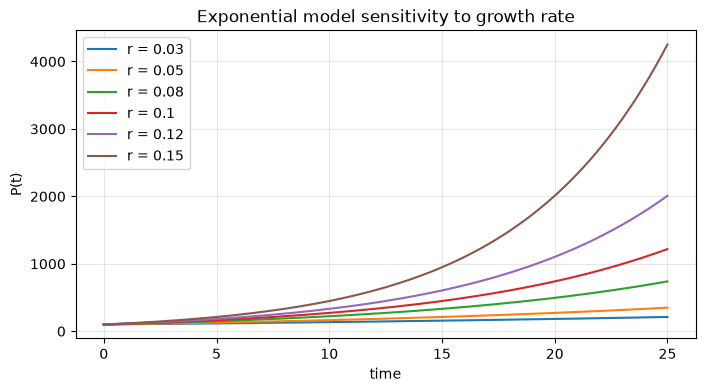

In [4]:
import numpy as np
import matplotlib.pylab as plt

# Numerical exploration of growth-rate effects
time = np.linspace(0, 25, 200)
P0_value = 100
r_values = [0.03, 0.05, 0.08, 0.10, 0.12, 0.15]

plt.figure(figsize=(8, 4))
for r_value in r_values:
    y = P0_value * np.exp(r_value * time)
    plt.plot(time, y, label=f"r = {r_value}")

plt.xlabel("time")
plt.ylabel("P(t)")
plt.title("Exponential model sensitivity to growth rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In your groups discuss what you learned.  As a class we will discuss the following

- Are there any common analytical components or functions in your own area of research?
- How might you use a symbolic library in your own research? 
- Where could you go to learn more about the sympy library.
- What is the fundamental difference between a library like sympy and a numerical library such as numpy.

# Advanced example

Consider a similar equation for calculating caffeine concentration in the bloodstream after drinking coffee:

$$C(t) = C_0 e^{-kt}$$

This is a useful starting point, but it becomes more interesting when we add repeated doses.

> You had coffee at 8 AM, another at noon, and another later in the afternoon.

This leads to a model like the following:

$$C(t) = C_0 e^{-kt} + \frac{1}{2}C_0 e^{-k(t-4)} + \frac{1}{4}C_0 e^{-k(t-8)}$$

where:

- $C_0$ is the caffeine concentration from a cup of coffee
- $k$ is the decay rate
- the second cup occurs 4 hours later
- the third cup occurs 8 hours later

Implement the equation in symbolic Python and try to answer the following questions:

- When is the caffeine concentration highest?
- When does it drop below some threshold?
- How long before I can fall asleep? 😄

In [16]:
# Put your example code here. 

t = sp.symbols("t", real=True)
C0, k = sp.symbols("C0 k", positive=True, real=True)
C = C0 * sp.exp(-k * t) + (1 / 2) * C0 * sp.exp(-k * (t - 4)) + (1/4) * C0 * sp.exp(-k * (t - 8))
C

c_prime = sp.diff(C, t)
crit_pts = sp.solve(c_prime, t)
crit_pts

#caf_max = sp.maximum(C, t)
#caf_max

[]

If your team is done with this go ahead and move on to the next notebook.